In [2]:
import pandas as pd 
import numpy as np, time, warnings
from sklearn.model_selection import train_test_split 
from feature_labels import create_features_and_labels
from scaling import scale_features
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm
import os 
import shap
import time

warnings.filterwarnings("ignore")


In [2]:
df = pd.read_parquet('processed_sepsis_data.parquet')

In [3]:
df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,97.0,95.0,36.11,98.0,75.33,0.0,19.0,0.0,24.0,45.0,...,0.0,317.0,83.14,0,0.0,0.0,-0.03,1,0,p000001
1,97.0,95.0,36.11,98.0,75.33,0.0,19.0,0.0,24.0,45.0,...,0.0,317.0,83.14,0,0.0,0.0,-0.03,2,0,p000001
2,89.0,99.0,36.11,122.0,86.00,0.0,22.0,0.0,24.0,45.0,...,0.0,317.0,83.14,0,0.0,0.0,-0.03,3,0,p000001
3,90.0,95.0,36.11,122.0,86.00,0.0,30.0,0.0,24.0,45.0,...,0.0,317.0,83.14,0,0.0,0.0,-0.03,4,0,p000001
4,103.0,88.5,36.11,122.0,91.33,0.0,24.5,0.0,24.0,45.0,...,0.0,317.0,83.14,0,0.0,0.0,-0.03,5,0,p000001


In [4]:
# we will split based on patient ID to prevent Data Leakage. We dont want to have data of same patient in training and testing as well. Risk of Biased training  

all_patients_id = df['patient_id'].unique()
print(f"Found{len(all_patients_id)} unique patients")


Found40336 unique patients


In [5]:
train_ids, test_ids = train_test_split(all_patients_id, test_size=0.2, random_state= 42)

In [6]:
test_ids.shape

(8068,)

In [7]:
train_ids.shape

(32268,)

In [8]:
# Create dataframes by selecting rows based on the patient ID lists
df_train= df[df['patient_id'].isin(train_ids)]
df_test= df[df['patient_id'].isin(test_ids)]

# Save Them 
df_train.to_parquet('train_dataset.parquet')
df_test.to_parquet('test_dataset.parquet')

print(f"Saved train_dataset.parquet. Shape: {df_train.shape}")
print(f"Saved test_dataset.parquet. Shape: {df_test.shape}")

Saved train_dataset.parquet. Shape: (1241213, 42)
Saved test_dataset.parquet. Shape: (310997, 42)


In [9]:
# Check the sanity of train and test dataset
train_patient_ids = set(df_train['patient_id'].unique())
test_patient_ids = set(df_test['patient_id'].unique())
    
# Find the intersection (patients in both sets)
overlap = train_patient_ids.intersection(test_patient_ids)

if len(overlap) == 0:
    print("SANITY CHECK PASSED: No patient overlap between train and test sets.")
else:
    print(f"SANITY CHECK FAILED: {len(overlap)} patients are in BOTH sets!")

SANITY CHECK PASSED: No patient overlap between train and test sets.


In [10]:
grouped_y = df_train.groupby('patient_id')['SepsisLabel']
y_label = grouped_y.shift(-1).rolling(6, min_periods=1).max()
df_train['SepsisLabel_6hr_lookahead'] = y_label.reset_index(level=0, drop=True)
df_train['SepsisLabel_6hr_lookahead'].fillna(0, inplace=True)
df_train.head(5)

C:\Users\shirs\AppData\Local\Temp\ipykernel_33696\3846532673.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['SepsisLabel_6hr_lookahead'] = y_label.reset_index(level=0, drop=True)
C:\Users\shirs\AppData\Local\Temp\ipykernel_33696\3846532673.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the ori

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,SepsisLabel_6hr_lookahead
0,97.0,95.0,36.11,98.0,75.33,0.0,19.0,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,1,0,p000001,0.0
1,97.0,95.0,36.11,98.0,75.33,0.0,19.0,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,2,0,p000001,0.0
2,89.0,99.0,36.11,122.0,86.00,0.0,22.0,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,3,0,p000001,0.0
3,90.0,95.0,36.11,122.0,86.00,0.0,30.0,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,4,0,p000001,0.0
4,103.0,88.5,36.11,122.0,91.33,0.0,24.5,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,5,0,p000001,0.0


In [11]:
df_train.head(2)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,SepsisLabel_6hr_lookahead
0,97.0,95.0,36.11,98.0,75.33,0.0,19.0,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,1,0,p000001,0.0
1,97.0,95.0,36.11,98.0,75.33,0.0,19.0,0.0,24.0,45.0,...,317.0,83.14,0,0.0,0.0,-0.03,2,0,p000001,0.0


In [12]:
X_train, y_train = create_features_and_labels(df_train, window_size=12)

--- Starting feature engineering for dataframe with shape (1241213, 43) ---
Creating 6-hour lookahead target (y)...


d:\Sepsis_Capstone\Project\feature_labels.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['SepsisLabel_6hr_lookahead'] = y_label
d:\Sepsis_Capstone\Project\feature_labels.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['SepsisLabel_6hr_lookahead'].fillna(0, in

Found 34 vitals/labs columns to engineer.
Calculating 12-hour rolling features (X)...
Calculating mean...
Calculating std dev...
Calculating max...
Combining all features...
Cleaning up NaNs...
--- Feature engineering complete! ---


In [13]:
X_train

,Age,Gender,HospAdmTime,Unit1,Unit2,patient_id,ICULOS,HR_mean_12hr,O2Sat_mean_12hr,Temp_mean_12hr,...,Phosphate_max_12hr,Potassium_max_12hr,Bilirubin_total_max_12hr,TroponinI_max_12hr,Hct_max_12hr,Hgb_max_12hr,PTT_max_12hr,WBC_max_12hr,Fibrinogen_max_12hr,Platelets_max_12hr
0,83.14,0,-0.03,0.0,0.0,p000001,1,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,83.14,0,-0.03,0.0,0.0,p000001,2,97.000000,95.000000,36.110000,...,3.3,3.8,0.3,0.0,37.2,12.5,0.0,5.7,0.0,317.0
2,83.14,0,-0.03,0.0,0.0,p000001,3,97.000000,95.000000,36.110000,...,3.3,3.8,0.3,0.0,37.2,12.5,0.0,5.7,0.0,317.0
3,83.14,0,-0.03,0.0,0.0,p000001,4,94.333333,96.333333,36.110000,...,3.3,3.8,0.3,0.0,37.2,12.5,0.0,5.7,0.0,317.0
4,83.14,0,-0.03,0.0,0.0,p000001,5,93.250000,96.000000,36.110000,...,3.3,3.8,0.3,0.0,37.2,12.5,0.0,5.7,0.0,317.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,62.00,0,0.00,0.0,0.0,p120000,31,78.166667,98.000000,36.691667,...,4.0,3.6,0.9,0.0,37.6,12.0,29.1,6.8,0.0,230.0
1552206,62.00,0,0.00,0.0,0.0,p120000,32,78.166667,97.750000,36.650000,...,4.0,3.6,0.9,0.0,37.1,11.6,29.1,5.4,0.0,216.0
1552207,62.00,0,0.00,0.0,0.0,p120000,33,77.666667,97.750000,36.608333,...,4.0,3.6,0.9,0.0,37.1,11.6,29.1,5.4,0.0,216.0
1552208,62.00,0,0.00,0.0,0.0,p120000,34,77.333333,97.666667,36.566667,...,4.0,3.6,0.9,0.0,37.1,11.6,29.1,5.4,0.0,216.0


In [14]:
y_train.to_frame().to_parquet("y_train.parquet")

In [15]:
X_test, y_test = create_features_and_labels(df_test, window_size=12)

--- Starting feature engineering for dataframe with shape (310997, 42) ---
Creating 6-hour lookahead target (y)...
Found 34 vitals/labs columns to engineer.
Calculating 12-hour rolling features (X)...
Calculating mean...


d:\Sepsis_Capstone\Project\feature_labels.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['SepsisLabel_6hr_lookahead'] = y_label
d:\Sepsis_Capstone\Project\feature_labels.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['SepsisLabel_6hr_lookahead'].fillna(0, in

Calculating std dev...
Calculating max...
Combining all features...
Cleaning up NaNs...
--- Feature engineering complete! ---


In [ ]:
X_test.to_parquet("X_test.parquet")
y_test.to_frame().to_parquet("y_test.parquet")

In [20]:
X_train_scaled, X_test_scaled = scale_features(
    X_train_path='X_train.parquet',
    X_test_path='X_test.parquet'
)

# Save the final scaled files
X_train_scaled.to_parquet('X_train_scaled.parquet')
X_test_scaled.to_parquet('X_test_scaled.parquet')


loaded X_train(1241213, 109) and X_test(310997, 109)
Found 107 features to scale.
Scaling Complete


In [4]:
# Load the Scaled Data

print("Loading data...")
try:
    X_train = pd.read_parquet('X_train_scaled.parquet')
    y_train = pd.read_parquet('y_train.parquet').values.ravel()
    X_test = pd.read_parquet('X_test_scaled.parquet')
    y_test = pd.read_parquet('y_test.parquet').values.ravel()
except FileNotFoundError:
    print("FATAL ERROR: Could not find scaled parquet files. Please re-run the scaling step.")
    raise

# Drop metadata for Training 

metadata = ['patient_id', 'ICULOS']
X_train_model = X_train.drop(columns=metadata, errors='ignore')
X_test_model = X_test.drop(columns=metadata, errors='ignore')

print(f"Training on {X_train_model.shape[0]} samples and {X_train_model.shape[1]} features.")

Loading data...
Training on 1241213 samples and 107 features.


In [10]:
# ==============================
# 1 Fast TQDM RandomizedSearchCV
# ==============================
class FastTQDMSearchCV(RandomizedSearchCV):
    """RandomizedSearchCV with lightweight tqdm progress bar."""
    def fit(self, X, y=None, **fit_params):
        total_candidates = getattr(self, "n_iter", None) or len(self.param_distributions)
        pbar = tqdm(total=total_candidates, desc="Tuning Progress", leave=True)
        old_run_search = self._run_search
        
        def new_run_search(evaluate_candidates):
            def wrapped(candidate_params):
                results = evaluate_candidates(candidate_params)
                pbar.update(len(candidate_params))
                return results
            old_run_search(wrapped)
        
        self._run_search = new_run_search
        
        try:
            result = super().fit(X, y, **fit_params)
        finally:
            pbar.close()
        
        return result

# ==============================
# 2 Sampling function
# ==============================
def get_sample(X, y, n_rows=100_000, random_state=42):
    """Return stratified sample of n_rows from X, y"""
    sss = StratifiedShuffleSplit(n_splits=1, test_size=len(X)-n_rows, random_state=random_state)
    train_idx, _ = next(sss.split(X, y))
    return X.iloc[train_idx], y[train_idx]

# ==============================
# 3 Tune Logistic Regression safely
# ==============================
def tune_logistic_regression(X_sample, y_sample, cv, n_iter=10):
    print(f"\n--- Tuning Logistic Regression on {X_sample.shape[0]} samples ---")
    start_time = time.time()
    
    # Decide safe n_jobs
    n_jobs = -1 if X_sample.shape[0] <= 100_000 else 1  # parallel only for small sample

    lr_param_grid = [
        {'penalty': ['l1','l2'], 'C': [0.01, 0.1, 1], 'solver': ['saga']}  # saga safe for large data
    ]

    lr_search = FastTQDMSearchCV(
        LogisticRegression(class_weight='balanced', max_iter=200, n_jobs=1, random_state=42),
        lr_param_grid,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        n_jobs=n_jobs,
        random_state=42
    )

    lr_search.fit(X_sample, y_sample)
    print(f"Best LR Params: {lr_search.best_params_}")
    print(f"Best LR CV AUROC: {lr_search.best_score_:.4f}")
    print(f"Tuning time: {(time.time() - start_time):.1f}s")
    return lr_search

# ==============================
# 4 Tune XGBoost safely
# ==============================
def tune_xgboost(X_sample, y_sample, cv, n_iter=10):
    print(f"\n--- Tuning XGBoost on {X_sample.shape[0]} samples ---")
    start_time = time.time()

    # scale_pos_weight for imbalance
    ratio = float(np.sum(y_sample == 0)) / np.sum(y_sample == 1)

    xgb_param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }


    # Always n_jobs=1 for safe tuning with large sample
    xgb_search = FastTQDMSearchCV(
        XGBClassifier(scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss', random_state=42),
        xgb_param_grid,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        random_state=42
    )

    xgb_search.fit(X_sample, y_sample)
    print(f"Best XGB Params: {xgb_search.best_params_}")
    print(f"Best XGB CV AUROC: {xgb_search.best_score_:.4f}")
    print(f"Tuning time: {(time.time() - start_time):.1f}s")
    return xgb_search.best_params_

# ==============================
# 5 Progressive tuning
# ==============================
# Step 1: small sample
X_sample_small, y_sample_small = get_sample(X_train_model, y_train, n_rows=100_000)
cv_small = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

best_lr_small = tune_logistic_regression(X_sample_small, y_sample_small, cv_small, n_iter=5)
best_xgb_small = tune_xgboost(X_sample_small, y_sample_small, cv_small, n_iter=5)

# Step 2: medium sample (safe size for notebook)
X_sample_medium, y_sample_medium = get_sample(X_train_model, y_train, n_rows=250_000)
cv_medium = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_lr_medium = tune_logistic_regression(X_sample_medium, y_sample_medium, cv_medium, n_iter=10).best_estimator_
best_xgb_medium = tune_xgboost(X_sample_medium, y_sample_medium, cv_medium, n_iter=10)

# ==============================
# 6 Retrain best models with best AUROC SCORE after the GRID search on full dataset
# ==============================
print("\n--- Retraining best model on FULL dataset ---")


# --- We are SKIPPING the slow Logistic Regression re-train ---
# Logistic Regression
"""
final_lr = LogisticRegression(
    **best_lr_medium,
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)
final_lr.fit(X_train_model, y_train)

# it is extremely lenghthy in nature due to its operation is mostly sequential in nature.
# Logistic Regression (even with saga) is solving one single, massive math problem: "What are the single best weights for all 107 features?" 
# This problem is much harder to break into 16 independent pieces. 
# While saga can use multiple cores for some of its steps, a large part of its work is sequential, meaning it has to wait for the previous step to finish.
"""

# XGBoost
final_ratio = float(np.sum(y_train==0)) / np.sum(y_train==1)
final_xgb = XGBClassifier(
    **best_xgb_medium,
    scale_pos_weight=final_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
final_xgb.fit(X_train_model, y_train,verbose=True)

print("Retraining complete.")




--- Tuning Logistic Regression on 100000 samples ---


Tuning Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Best LR Params: {'solver': 'saga', 'penalty': 'l1', 'C': 0.01}
Best LR CV AUROC: 0.6114
Tuning time: 142.2s

--- Tuning XGBoost on 100000 samples ---


Tuning Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Best XGB Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best XGB CV AUROC: 0.6421
Tuning time: 15.2s

--- Tuning Logistic Regression on 250000 samples ---


Tuning Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Best LR Params: {'solver': 'saga', 'penalty': 'l1', 'C': 0.01}
Best LR CV AUROC: 0.6157
Tuning time: 1449.7s

--- Tuning XGBoost on 250000 samples ---


Tuning Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best XGB CV AUROC: 0.7210
Tuning time: 71.9s

--- Retraining best model on FULL dataset ---
Retraining complete.


In [11]:
# Final evaluation
print("\n--- Test Set Evaluation ---")

# For LR, we use the best one we found in the *search*
lr_probs = best_lr_medium.predict_proba(X_test_model)[:, 1]
lr_final_auroc = roc_auc_score(y_test, lr_probs)
lr_final_auprc = average_precision_score(y_test, lr_probs)
print(f"Logistic Regression (from 250k sample) Test AUROC: {lr_final_auroc:.4f}")
print(f"Logistic Regression (from 250k sample) Test AUPRC: {lr_final_auprc:.4f}")

# For XGB, we use the final, re-trained model
xgb_probs = final_xgb.predict_proba(X_test_model)[:, 1]
xgb_final_auroc = roc_auc_score(y_test, xgb_probs)
xgb_final_auprc = average_precision_score(y_test, xgb_probs)
print(f"XGBoost (Full Data) Test AUROC: {xgb_final_auroc:.4f}")
print(f"XGBoost (Full Data) Test AUPRC: {xgb_final_auprc:.4f}")



--- Test Set Evaluation ---
Logistic Regression (from 250k sample) Test AUROC: 0.7285
Logistic Regression (from 250k sample) Test AUPRC: 0.0092
XGBoost (Full Data) Test AUROC: 0.7508
XGBoost (Full Data) Test AUPRC: 0.0094


In [12]:
# Load the y_test data
y_test = pd.read_parquet('y_test.parquet').values.ravel()

# Calculate the baseline
baseline = np.sum(y_test == 1) / len(y_test)
print(f"Baseline AUPRC (Prevalence of Sepsis): {baseline:.4f}")

Baseline AUPRC (Prevalence of Sepsis): 0.0048


In [13]:
# Combine them for easy filtering
X_train['SepsisLabel_6hr_lookahead'] = y_train

# --- Create the Undersampled Dataset ---
print(f"Original training data: {X_train.shape[0]} rows")
positive_cases = X_train[X_train['SepsisLabel_6hr_lookahead'] == 1]
negative_cases = X_train[X_train['SepsisLabel_6hr_lookahead'] == 0]

# Let's use a 3:1 (Healthy:Sepsis) ratio to keep more data
n_neg_samples = positive_cases.shape[0] * 3 
negative_sample = negative_cases.sample(n=n_neg_samples, random_state=42)

# Combine to create our new, balanced training set
df_train_undersampled = pd.concat([positive_cases, negative_sample])
print(f"New undersampled data: {df_train_undersampled.shape[0]} rows")

# Separate X and y again
y_train_new = df_train_undersampled['SepsisLabel_6hr_lookahead'].values.ravel()
X_train_new = df_train_undersampled.drop(columns=['patient_id', 'ICULOS', 'SepsisLabel_6hr_lookahead'], errors='ignore')

# --- 3. Re-Train Your Best XGBoost Model ---
try:
    best_xgb_params = best_xgb_medium
except NameError:
    print("FATAL ERROR: 'best_xgb_medium_params' not found.")
    print("Please re-run the main tuning script cell (Part 6) first.")
    raise

# We need to re-calculate the scale_pos_weight for this NEW dataset
new_ratio = float(np.sum(y_train_new == 0)) / np.sum(y_train_new == 1) # This will be 3.0

final_xgb_undersampled = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=new_ratio, # Use the new 3:1 ratio
    n_jobs=-1,
    random_state=42
)

print("Re-training XGBoost on undersampled data...")
start_time = time.time()
final_xgb_undersampled.fit(X_train_new, y_train_new, verbose=True)
print(f"Re-training complete in {(time.time() - start_time)/60:.1f} minutes.")

# --- 4. Evaluate on the SAME Test Set ---
print("\n--- Final Test Set Evaluation (Undersampled Model) ---")
# Load the original, full test set
X_test = pd.read_parquet('X_test_scaled.parquet').drop(columns=['patient_id', 'ICULOS'], errors='ignore')
y_test = pd.read_parquet('y_test.parquet').values.ravel()

xgb_probs_new = final_xgb_undersampled.predict_proba(X_test)[:, 1]
xgb_auroc_new = roc_auc_score(y_test, xgb_probs_new)
xgb_auprc_new = average_precision_score(y_test, xgb_probs_new)

print(f"XGBoost (Undersampled) Test AUROC: {xgb_auroc_new:.4f}")
print(f"XGBoost (Undersampled) Test AUPRC: {xgb_auprc_new:.4f}")

print("\n--- Comparison ---")
print(f"Original AUPRC: {xgb_final_auprc:.4f}") # 'xgb_final_auprc' is from your previous cell
print(f"New AUPRC:      {xgb_auprc_new:.4f}")

Original training data: 1241213 rows
New undersampled data: 109780 rows
Re-training XGBoost on undersampled data...
Re-training complete in 0.0 minutes.

--- Final Test Set Evaluation (Undersampled Model) ---
XGBoost (Undersampled) Test AUROC: 0.7283
XGBoost (Undersampled) Test AUPRC: 0.0084

--- Comparison ---
Original AUPRC: 0.0094
New AUPRC:      0.0084


Saved final_roc_comparison.png


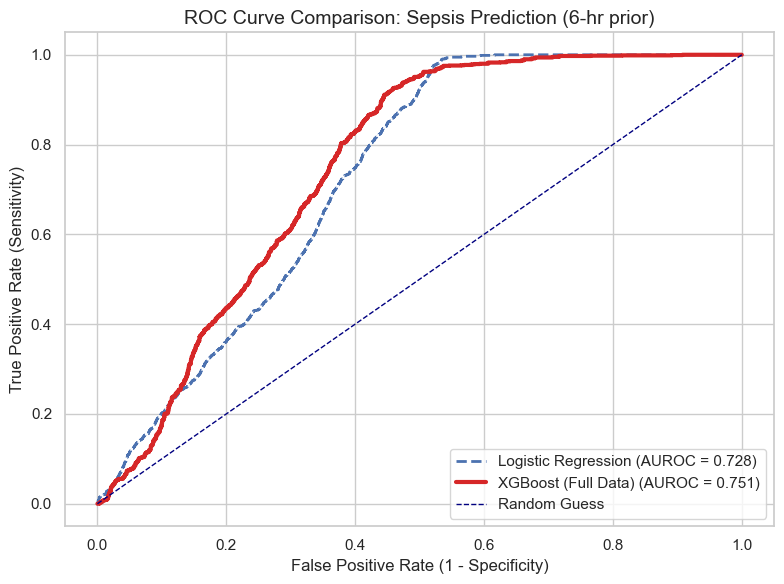

Saved final_prc_comparison.png


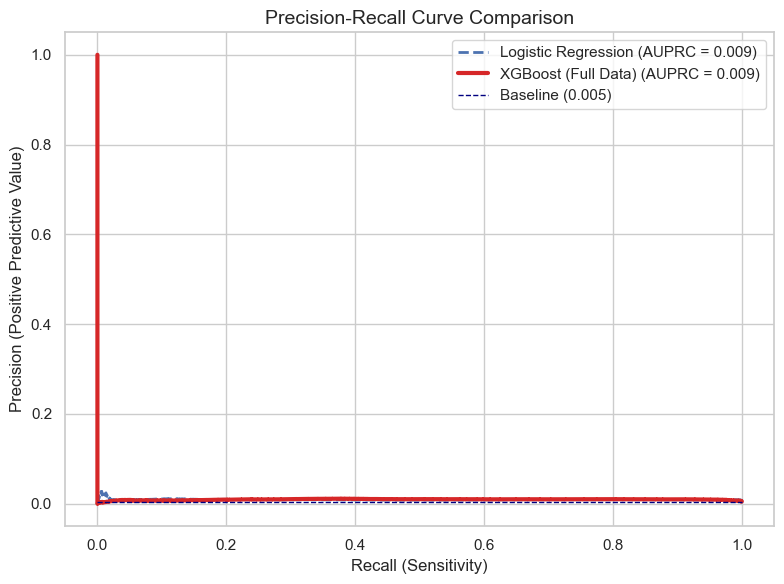

In [14]:
sns.set_theme(style="whitegrid")

# 1. Get Probabilities (uses variables from memory)
lr_probs = best_lr_medium.predict_proba(X_test_model)[:, 1]
xgb_probs = final_xgb.predict_proba(X_test_model)[:, 1]

# --- PLOT 1: ROC Curve Comparison ---
fig, ax = plt.subplots(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUROC = {roc_auc_lr:.3f})', linestyle='--', lw=2)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (Full Data) (AUROC = {roc_auc_xgb:.3f})', lw=3, color='#d62728')

ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve Comparison: Sepsis Prediction (6-hr prior)', fontsize=14)
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig('final_roc_comparison.png', dpi=300)
print("Saved final_roc_comparison.png")
plt.show()

# --- PLOT 2: Precision-Recall Curve Comparison ---
fig, ax = plt.subplots(figsize=(8, 6))

precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probs)
auprc_lr = average_precision_score(y_test, lr_probs)
ax.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUPRC = {auprc_lr:.3f})', linestyle='--', lw=2)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)
auprc_xgb = average_precision_score(y_test, xgb_probs)
ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (Full Data) (AUPRC = {auprc_xgb:.3f})', lw=3, color='#d62728')

baseline = np.sum(y_test == 1) / len(y_test)
ax.plot([0, 1], [baseline, baseline], color='navy', lw=1, linestyle='--', label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.savefig('final_prc_comparison.png', dpi=300)
print("Saved final_prc_comparison.png")
plt.show()

Creating SHAP explainer...


 99%|===================| 9863/10000 [00:38<00:00]        

SHAP values calculated.
Saving SHAP summary plot...
Saved final_shap_summary.png

--- SHAP Analysis Complete ---


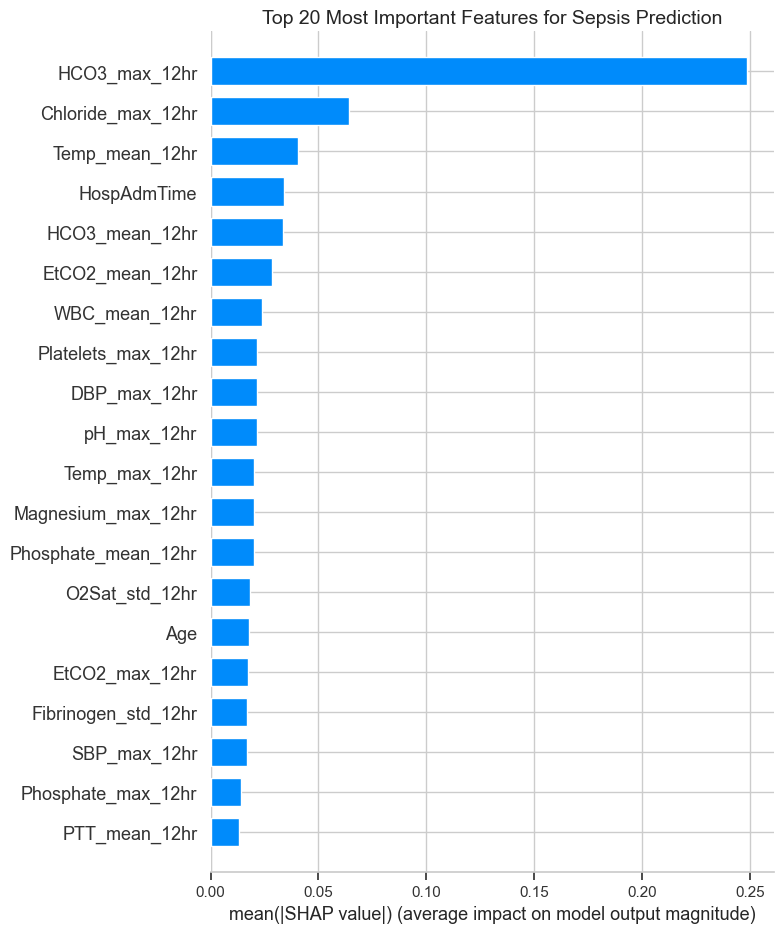

In [15]:
# 1. Create a SHAP Explainer
# 'final_xgb' and 'X_train_model' are already in memory
print("Creating SHAP explainer...")
# We use a sample of the training data for speed, which is standard
X_sample_shap = shap.sample(X_train_model, 10000, random_state=42)
explainer = shap.Explainer(final_xgb, X_sample_shap)
shap_values = explainer(X_sample_shap)

print("SHAP values calculated.")

# 2. Create and save the summary plot
print("Saving SHAP summary plot...")
shap.summary_plot(
    shap_values, 
    X_sample_shap, 
    plot_type="bar", 
    show=False
)
plt.title('Top 20 Most Important Features for Sepsis Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('final_shap_summary.png', dpi=300)
print("Saved final_shap_summary.png")

print("\n--- SHAP Analysis Complete ---")

Finding best threshold based on F1-Score...
Best Threshold found: 0.5775
This threshold gives F1: 0.0218
At this threshold: Precision=0.0112, Recall=0.3738
Plotting Confusion Matrix...
Saved final_confusion_matrix.png


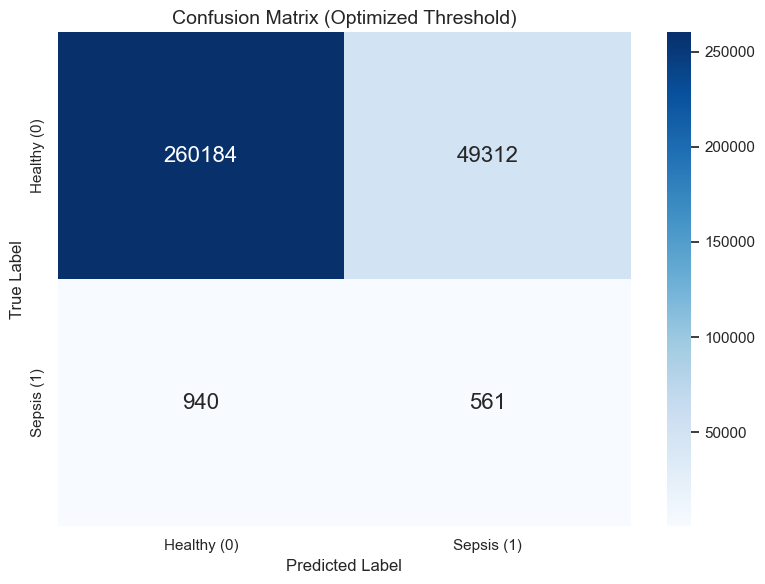

In [16]:
# 1. Get Probabilities (uses variables from memory)

xgb_probs = final_xgb.predict_proba(X_test_model)[:, 1]

# 2. Find the Best Threshold
print("Finding best threshold based on F1-Score...")
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)

# Calculate F1-Score for each threshold
# (Adding a small value to avoid division by zero)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)

# Find the threshold that gives the max F1-score
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]

print(f"Best Threshold found: {best_threshold:.4f}")
print(f"This threshold gives F1: {f1_scores[best_f1_idx]:.4f}")
print(f"At this threshold: Precision={precision[best_f1_idx]:.4f}, Recall={recall[best_f1_idx]:.4f}")

# 3. Create Predictions using the NEW Threshold
y_pred_new_threshold = (xgb_probs >= best_threshold).astype(int)

# 4. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_new_threshold)

# 5. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, annot_kws={"size": 16})

ax.set_title('Confusion Matrix (Optimized Threshold)', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.xaxis.set_ticklabels(['Healthy (0)', 'Sepsis (1)'])
ax.yaxis.set_ticklabels(['Healthy (0)', 'Sepsis (1)'])
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=300)
print("Saved final_confusion_matrix.png")
plt.show()